# QTL knockout validation after removal of the most deviant replicate

This notebook generates:

- Four **OD600** figures: one 1×4 figure for each QTL.
- Four **fitness-defect (FD)** figures: one 1×4 figure for each QTL.
- One subplot per concentration: `0×`, `0.25×`, `0.50×`, and `1× MIC`.
- All KO strains plus **BY** in every subplot.
- Mean ± SE calculated from the **two retained replicates**.

## Fitness-defect definition

FD is first calculated from all three replicate-matched measurements:

\[
FD_{i,c,r}
=
\log_2\left(
\frac{OD_{i,c,r}}
{OD_{i,0\times,r}}
\right)
\]

where \(i\) is the strain, \(c\) is the concentration, and \(r\) is the replicate.

## Most-deviant replicate removal

For each QTL × strain × concentration:

1. Calculate the median of Rep1–Rep3.
2. Calculate each replicate's absolute distance from the median.
3. Remove the replicate with the largest distance.
4. If distances tie, use distance from the mean as a secondary rule.
5. If the tie remains, remove the replicate with the largest replicate number.

Replicate removal is performed **independently for OD600 and FD**, because the most deviant OD600 value is not necessarily the most deviant FD value.

The notebook exports audit tables identifying every removed replicate.


In [1]:
# Cell 1 — Imports and plotting settings

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
# Cell 2 — Working directory, input files, and output folders

WORKING_DIR = Path(
    "/blue/juannanzhou/arindam.sarkar/"
    "BB-QTL_HT/7_HIPHOP_validation/Dose-dependent"
)

INPUT_DIR = WORKING_DIR / "inputs"


# Update only these filenames if the files in INPUT_DIR have different names.
BY_FILE = INPUT_DIR / "BY.xlsx"

QTL_FILES = {
    "Chr7 QTL": INPUT_DIR / "CHR7_QTL.xlsx",
    "Chr8 QTL": INPUT_DIR / "CHR8_QTL.xlsx",
    "Chr13 QTL": INPUT_DIR / "CHR13_QTL.xlsx",
    "Chr15 QTL": INPUT_DIR / "CHR15_QTL.xlsx",
}


CONCENTRATION_ORDER = [
    "0x",
    "0.25x",
    "0.50x",
    "1.0x",
]

CONCENTRATION_TITLES = {
    "0x": "0× MIC",
    "0.25x": "0.25× MIC",
    "0.50x": "0.5× MIC",
    "1.0x": "1× MIC",
}


OD_OUTDIR = (
    WORKING_DIR
    / "OD600_1x4_figures_deviant_removed"
)

FD_OUTDIR = (
    WORKING_DIR
    / "FD_1x4_figures_deviant_removed"
)

SUMMARY_OUTDIR = (
    WORKING_DIR
    / "summary_tables_deviant_removed"
)


for folder in [
    OD_OUTDIR,
    FD_OUTDIR,
    SUMMARY_OUTDIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


if not WORKING_DIR.exists():
    raise FileNotFoundError(
        f"Working directory not found:\n{WORKING_DIR}"
    )

if not INPUT_DIR.exists():
    raise FileNotFoundError(
        f"Input directory not found:\n{INPUT_DIR}"
    )


required_files = [
    BY_FILE,
    *QTL_FILES.values(),
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following input files were not found:\n\n"
        + "\n".join(missing_files)
        + "\n\nCheck the filenames in INPUT_DIR."
    )


print("All input files found.")
print("\nWorking directory:", WORKING_DIR)
print("Input directory:", INPUT_DIR)
print("\nOutput directories:")
print("  OD600:", OD_OUTDIR)
print("  FD:", FD_OUTDIR)
print("  Summaries and audit tables:", SUMMARY_OUTDIR)


All input files found.

Working directory: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent
Input directory: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/inputs

Output directories:
  OD600: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/OD600_1x4_figures_deviant_removed
  FD: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/FD_1x4_figures_deviant_removed
  Summaries and audit tables: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables_deviant_removed


In [3]:
# ==========================================================
# Cell 3 — Functions to read and reshape the Excel workbooks
# ==========================================================

# Correct regex:
#   \s+   = one or more spaces
#   \d+   = one or more digits
#
# Examples recognized:
#   BY Rep1
#   ERG4 Rep2
#   YHR007C-A Rep3

COLUMN_PATTERN = re.compile(
    r"^(.*?)\s+Rep\s*(\d+)$",
    flags=re.IGNORECASE
)


def read_excel_wide(
    file_path: Path
) -> pd.DataFrame:
    """
    Read one workbook and standardize its first column
    as 'Concentration'.
    """

    df = pd.read_excel(file_path)

    if df.empty:
        raise ValueError(
            f"{file_path.name} is empty."
        )

    # Remove accidental leading/trailing spaces from headers
    df.columns = [
        str(column).strip()
        for column in df.columns
    ]

    # The first column contains drug concentration
    df = df.rename(
        columns={
            df.columns[0]: "Concentration"
        }
    )

    df["Concentration"] = (
        df["Concentration"]
        .astype(str)
        .str.strip()
    )

    observed = set(
        df["Concentration"]
    )

    unexpected = sorted(
        observed
        - set(CONCENTRATION_ORDER)
    )

    if unexpected:
        raise ValueError(
            f"{file_path.name} contains unexpected "
            f"concentration labels: {unexpected}\n"
            f"Expected: {CONCENTRATION_ORDER}"
        )

    missing = [
        concentration
        for concentration in CONCENTRATION_ORDER
        if concentration not in observed
    ]

    if missing:
        raise ValueError(
            f"{file_path.name} is missing "
            f"concentrations: {missing}"
        )

    return df


def wide_to_long(
    df: pd.DataFrame,
    source_file: str
) -> pd.DataFrame:
    """
    Convert columns such as:

        BY Rep1
        ERG4 Rep2
        YHR007C-A Rep3

    into tidy columns:

        Concentration
        Strain
        Replicate
        OD600
    """

    long_parts = []

    for column in df.columns:

        if column == "Concentration":
            continue

        # Normalize whitespace in the column name
        column_name = " ".join(
            str(column).strip().split()
        )

        match = COLUMN_PATTERN.fullmatch(
            column_name
        )

        if match is None:
            raise ValueError(
                f"Could not interpret column {column!r} "
                f"in {source_file}.\n"
                "Expected format '<strain> Rep<number>', "
                "for example 'ERG4 Rep1'."
            )

        strain = match.group(1).strip()
        replicate = int(
            match.group(2)
        )

        if strain == "":
            raise ValueError(
                f"Missing strain name in column "
                f"{column!r} from {source_file}."
            )

        part = df[
            [
                "Concentration",
                column
            ]
        ].copy()

        part = part.rename(
            columns={
                column: "OD600"
            }
        )

        part["Strain"] = strain
        part["Replicate"] = replicate
        part["Source_file"] = source_file

        long_parts.append(
            part
        )

    if not long_parts:
        raise ValueError(
            f"No replicate columns were detected "
            f"in {source_file}."
        )

    long_df = pd.concat(
        long_parts,
        ignore_index=True
    )

    long_df["OD600"] = pd.to_numeric(
        long_df["OD600"],
        errors="coerce"
    )

    if long_df["OD600"].isna().any():

        bad_rows = long_df.loc[
            long_df["OD600"].isna(),
            [
                "Concentration",
                "Strain",
                "Replicate",
                "OD600"
            ]
        ]

        raise ValueError(
            f"Missing or nonnumeric OD600 values "
            f"were found in {source_file}:\n\n"
            + bad_rows.to_string(index=False)
        )

    expected_replicates = {
        1,
        2,
        3
    }

    observed_replicates = set(
        long_df["Replicate"].unique()
    )

    if observed_replicates != expected_replicates:
        raise ValueError(
            f"{source_file} contains replicate numbers "
            f"{sorted(observed_replicates)}.\n"
            "Expected exactly Rep1, Rep2, and Rep3."
        )

    return long_df

In [4]:
# Cell 4 — Load BY and append it to every QTL dataset

by_wide = read_excel_wide(
    BY_FILE
)

by_long = wide_to_long(
    by_wide,
    BY_FILE.name,
)


if set(by_long["Strain"].unique()) != {"BY"}:
    raise ValueError(
        f"{BY_FILE.name} should contain only BY, "
        f"but found: {sorted(by_long['Strain'].unique())}"
    )


qtl_data = {}


for qtl_name, qtl_file in QTL_FILES.items():

    qtl_wide = read_excel_wide(
        qtl_file
    )

    qtl_long = wide_to_long(
        qtl_wide,
        qtl_file.name,
    )

    if "BY" in set(
        qtl_long["Strain"]
    ):
        raise ValueError(
            f"{qtl_file.name} already contains BY. "
            "Remove BY from the QTL workbook because "
            "it is appended from the separate BY workbook."
        )

    # Append BY to all KO strains.
    combined = pd.concat(
        [
            qtl_long,
            by_long.copy(),
        ],
        ignore_index=True,
    )

    combined["Concentration"] = pd.Categorical(
        combined["Concentration"],
        categories=CONCENTRATION_ORDER,
        ordered=True,
    )

    combined = combined.sort_values(
        [
            "Concentration",
            "Strain",
            "Replicate",
        ]
    ).reset_index(drop=True)

    qtl_data[qtl_name] = combined


for qtl_name, df in qtl_data.items():

    ko_strains = [
        strain
        for strain in df["Strain"].drop_duplicates()
        if strain != "BY"
    ]

    strain_order = (
        ko_strains
        + ["BY"]
    )

    print(f"\n{qtl_name}")
    print("Strains:", ", ".join(strain_order))
    print("BY appended:", "BY" in strain_order)



Chr7 QTL
Strains: ERG4, PDR1, BY
BY appended: True

Chr8 QTL
Strains: ERG11, STP2, YHR007C-A, BY
BY appended: True

Chr13 QTL
Strains: ADH6, FET4, YMR317W, YMR320W, BY
BY appended: True

Chr15 QTL
Strains: DUF1, ELG1, HAL9, MDM32, MPD2, MSH2, PNO1, SPP2, BY
BY appended: True


In [5]:
# Cell 5 — Calculate replicate-wise Fitness Defect from all three replicates

def calculate_fitness_defect(
    long_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculate Fitness Defect for each strain and replicate:

        FD = log2(
            OD600_treatment
            /
            OD600_0x
        )

    Each treatment replicate is normalized to the untreated
    measurement of the same strain and replicate.
    """

    df = long_df.copy()

    baseline = (
        df.loc[
            df["Concentration"] == "0x",
            [
                "Strain",
                "Replicate",
                "OD600",
            ],
        ]
        .rename(
            columns={
                "OD600": "OD600_0x"
            }
        )
    )

    duplicated_baselines = baseline.duplicated(
        subset=[
            "Strain",
            "Replicate",
        ],
        keep=False,
    )

    if duplicated_baselines.any():
        raise ValueError(
            "More than one 0x baseline was found for "
            "at least one strain-replicate."
        )

    df = df.merge(
        baseline,
        on=[
            "Strain",
            "Replicate",
        ],
        how="left",
        validate="many_to_one",
    )

    if df["OD600_0x"].isna().any():
        raise ValueError(
            "A 0x baseline is missing for at least one "
            "strain-replicate."
        )

    if (df["OD600"] <= 0).any():
        raise ValueError(
            "All OD600 values must be greater than zero "
            "before calculating log2 FD."
        )

    if (df["OD600_0x"] <= 0).any():
        raise ValueError(
            "All untreated OD600 values must be greater "
            "than zero."
        )

    df["FD"] = np.log2(
        df["OD600"]
        /
        df["OD600_0x"]
    )

    return df


qtl_data_with_fd = {
    qtl_name: calculate_fitness_defect(df)
    for qtl_name, df in qtl_data.items()
}


for qtl_name, df in qtl_data_with_fd.items():

    untreated_fd = df.loc[
        df["Concentration"] == "0x",
        "FD",
    ]

    if not np.allclose(
        untreated_fd,
        0.0,
    ):
        raise ValueError(
            f"Untreated FD values are not zero for {qtl_name}."
        )


print(
    "Fitness Defect calculated successfully "
    "from all three replicates."
)


Fitness Defect calculated successfully from all three replicates.


In [6]:
# Cell 6 — Function to remove the most deviant replicate

def remove_most_deviant_replicate(
    long_df: pd.DataFrame,
    metric: str,
    group_columns=None,
):
    """
    Remove one most-deviant replicate from every group.

    The default group is:
        Concentration × Strain

    The most deviant value is the observation with the largest
    absolute distance from the median of Rep1–Rep3.

    Tie-breaking:
    1. Largest absolute distance from the median.
    2. Largest absolute distance from the mean.
    3. Largest replicate number.

    Returns
    -------
    filtered_df
        Data containing the two retained replicates.

    removal_log
        Audit table identifying the removed replicate.
    """

    if group_columns is None:
        group_columns = [
            "Concentration",
            "Strain",
        ]

    required_columns = set(
        group_columns
        + [
            "Replicate",
            metric,
        ]
    )

    missing_columns = (
        required_columns
        - set(long_df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"Missing required columns for {metric}: "
            f"{sorted(missing_columns)}"
        )

    kept_groups = []
    removal_records = []

    grouped = long_df.groupby(
        group_columns,
        observed=True,
        sort=False,
        dropna=False,
    )

    for group_key, group_df in grouped:

        group_df = (
            group_df
            .copy()
            .sort_values("Replicate")
            .reset_index(drop=True)
        )

        if len(group_df) != 3:
            raise ValueError(
                f"Expected three observations for "
                f"{group_columns} = {group_key}, "
                f"but found {len(group_df)}."
            )

        if group_df[metric].isna().any():
            raise ValueError(
                f"Missing {metric} value for "
                f"{group_columns} = {group_key}."
            )

        values = group_df[
            metric
        ].astype(float)

        group_median = values.median()
        group_mean = values.mean()

        group_df[
            "_distance_from_median"
        ] = (
            group_df[metric]
            - group_median
        ).abs()

        maximum_median_distance = (
            group_df[
                "_distance_from_median"
            ].max()
        )

        median_candidates = group_df.loc[
            np.isclose(
                group_df[
                    "_distance_from_median"
                ],
                maximum_median_distance,
            )
        ].copy()

        median_tie = (
            len(median_candidates) > 1
        )

        median_candidates[
            "_distance_from_mean"
        ] = (
            median_candidates[metric]
            - group_mean
        ).abs()

        maximum_mean_distance = (
            median_candidates[
                "_distance_from_mean"
            ].max()
        )

        final_candidates = median_candidates.loc[
            np.isclose(
                median_candidates[
                    "_distance_from_mean"
                ],
                maximum_mean_distance,
            )
        ].copy()

        final_tie = (
            len(final_candidates) > 1
        )

        removed_row = (
            final_candidates
            .sort_values(
                "Replicate",
                ascending=False,
            )
            .iloc[0]
        )

        removed_replicate = int(
            removed_row["Replicate"]
        )

        kept_group = group_df.loc[
            group_df["Replicate"]
            != removed_replicate
        ].copy()

        kept_group = kept_group.drop(
            columns=[
                "_distance_from_median",
            ],
            errors="ignore",
        )

        kept_groups.append(
            kept_group
        )

        if not isinstance(
            group_key,
            tuple,
        ):
            group_key = (
                group_key,
            )

        record = {
            column: value
            for column, value
            in zip(
                group_columns,
                group_key,
            )
        }

        record.update({
            "Metric": metric,
            "Removed_replicate": removed_replicate,
            "Removed_value": float(
                removed_row[metric]
            ),
            "Group_median": float(
                group_median
            ),
            "Group_mean": float(
                group_mean
            ),
            "Absolute_distance_from_median": float(
                removed_row[
                    "_distance_from_median"
                ]
            ),
            "Median_distance_tie": bool(
                median_tie
            ),
            "Final_tie_after_mean_check": bool(
                final_tie
            ),
            "Remaining_replicates": ", ".join(
                f"Rep{int(rep)}"
                for rep in sorted(
                    kept_group[
                        "Replicate"
                    ].unique()
                )
            ),
        })

        removal_records.append(
            record
        )

    filtered_df = pd.concat(
        kept_groups,
        ignore_index=True,
    )

    removal_log = pd.DataFrame(
        removal_records
    )

    return filtered_df, removal_log


In [7]:
# Cell 7 — Remove the most deviant replicate independently for OD600 and FD

qtl_od_trimmed = {}
qtl_fd_trimmed = {}

od_removal_logs = []
fd_removal_logs = []


for qtl_name, df in qtl_data_with_fd.items():

    # OD600-based removal
    od_filtered, od_log = (
        remove_most_deviant_replicate(
            long_df=df,
            metric="OD600",
            group_columns=[
                "Concentration",
                "Strain",
            ],
        )
    )

    od_filtered["QTL"] = qtl_name
    od_log["QTL"] = qtl_name

    qtl_od_trimmed[
        qtl_name
    ] = od_filtered

    od_removal_logs.append(
        od_log
    )


    # FD-based removal
    fd_filtered, fd_log = (
        remove_most_deviant_replicate(
            long_df=df,
            metric="FD",
            group_columns=[
                "Concentration",
                "Strain",
            ],
        )
    )

    fd_filtered["QTL"] = qtl_name
    fd_log["QTL"] = qtl_name

    qtl_fd_trimmed[
        qtl_name
    ] = fd_filtered

    fd_removal_logs.append(
        fd_log
    )


OD_REMOVAL_LOG = pd.concat(
    od_removal_logs,
    ignore_index=True,
)

FD_REMOVAL_LOG = pd.concat(
    fd_removal_logs,
    ignore_index=True,
)


OD_REMOVAL_LOG.to_csv(
    SUMMARY_OUTDIR
    / "OD600_removed_replicates.csv",
    index=False,
)

FD_REMOVAL_LOG.to_csv(
    SUMMARY_OUTDIR
    / "FD_removed_replicates.csv",
    index=False,
)


print(
    "Most-deviant replicate removal completed."
)

print(
    "\nOD600 removal log:",
    SUMMARY_OUTDIR
    / "OD600_removed_replicates.csv",
)

print(
    "FD removal log:",
    SUMMARY_OUTDIR
    / "FD_removed_replicates.csv",
)


Most-deviant replicate removal completed.

OD600 removal log: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables_deviant_removed/OD600_removed_replicates.csv
FD removal log: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables_deviant_removed/FD_removed_replicates.csv


In [8]:
# Cell 8 — Validate retained replicates and confirm BY in every panel

def validate_trimmed_dataset(
    qtl_datasets: dict,
    metric: str,
) -> pd.DataFrame:
    """
    Confirm that each strain-concentration group contains
    two retained replicates and that BY is present in every panel.
    """

    validation_rows = []

    for qtl_name, df in qtl_datasets.items():

        counts = (
            df.groupby(
                [
                    "Concentration",
                    "Strain",
                ],
                observed=True,
            )
            .size()
            .reset_index(
                name="Retained_n"
            )
        )

        invalid_counts = counts.loc[
            counts["Retained_n"] != 2
        ]

        if not invalid_counts.empty:
            raise ValueError(
                f"{metric}: groups with retained n != 2 "
                f"were found in {qtl_name}:\n\n"
                + invalid_counts.to_string(index=False)
            )

        for concentration in CONCENTRATION_ORDER:

            panel = df.loc[
                df["Concentration"]
                == concentration
            ]

            by_panel = panel.loc[
                panel["Strain"] == "BY"
            ]

            validation_rows.append({
                "Metric": metric,
                "QTL": qtl_name,
                "Concentration": concentration,
                "BY_present": not by_panel.empty,
                "BY_retained_replicates": (
                    by_panel[
                        "Replicate"
                    ].nunique()
                ),
                "Total_strains": (
                    panel[
                        "Strain"
                    ].nunique()
                ),
            })

    validation_df = pd.DataFrame(
        validation_rows
    )

    if not validation_df[
        "BY_present"
    ].all():
        raise ValueError(
            f"BY is missing from at least one {metric} panel."
        )

    if not (
        validation_df[
            "BY_retained_replicates"
        ] == 2
    ).all():
        raise ValueError(
            f"BY does not have two retained replicates "
            f"in every {metric} panel."
        )

    return validation_df


OD_VALIDATION = validate_trimmed_dataset(
    qtl_datasets=qtl_od_trimmed,
    metric="OD600",
)

FD_VALIDATION = validate_trimmed_dataset(
    qtl_datasets=qtl_fd_trimmed,
    metric="FD",
)


validation_output = pd.concat(
    [
        OD_VALIDATION,
        FD_VALIDATION,
    ],
    ignore_index=True,
)

validation_output.to_csv(
    SUMMARY_OUTDIR
    / "trimmed_dataset_validation.csv",
    index=False,
)


print(
    "Validation passed: every group contains two "
    "retained replicates, and BY is present in every subplot."
)

validation_output


Validation passed: every group contains two retained replicates, and BY is present in every subplot.


,Metric,QTL,Concentration,BY_present,BY_retained_replicates,Total_strains
0,OD600,Chr7 QTL,0x,True,2,3
1,OD600,Chr7 QTL,0.25x,True,2,3
2,OD600,Chr7 QTL,0.50x,True,2,3
3,OD600,Chr7 QTL,1.0x,True,2,3
4,OD600,Chr8 QTL,0x,True,2,4
5,OD600,Chr8 QTL,0.25x,True,2,4
6,OD600,Chr8 QTL,0.50x,True,2,4
7,OD600,Chr8 QTL,1.0x,True,2,4
8,OD600,Chr13 QTL,0x,True,2,5
9,OD600,Chr13 QTL,0.25x,True,2,5


In [9]:
# Cell 9 — Calculate mean and SE from the two retained replicates

def summarize_trimmed_metric(
    long_df: pd.DataFrame,
    metric: str,
) -> pd.DataFrame:
    """
    Calculate mean, SD, and SE from the two retained replicates.

        SE = SD / sqrt(2)
    """

    summary = (
        long_df
        .groupby(
            [
                "Concentration",
                "Strain",
            ],
            observed=True,
            sort=False,
        )[metric]
        .agg(
            n="count",
            mean="mean",
            sd="std",
            minimum="min",
            maximum="max",
        )
        .reset_index()
    )

    summary["SE"] = (
        summary["sd"]
        /
        np.sqrt(
            summary["n"]
        )
    )

    invalid_n = summary.loc[
        summary["n"] != 2
    ]

    if not invalid_n.empty:
        raise ValueError(
            f"Some {metric} groups do not contain "
            "exactly two retained replicates:\n\n"
            + invalid_n.to_string(index=False)
        )

    return summary


OD_TRIMMED_SUMMARIES = {
    qtl_name: summarize_trimmed_metric(
        long_df=df,
        metric="OD600",
    )
    for qtl_name, df
    in qtl_od_trimmed.items()
}


FD_TRIMMED_SUMMARIES = {
    qtl_name: summarize_trimmed_metric(
        long_df=df,
        metric="FD",
    )
    for qtl_name, df
    in qtl_fd_trimmed.items()
}


for qtl_name in QTL_FILES:

    safe_qtl = qtl_name.replace(
        " ",
        "_",
    )

    OD_TRIMMED_SUMMARIES[
        qtl_name
    ].to_csv(
        SUMMARY_OUTDIR
        / f"{safe_qtl}_OD600_trimmed_mean_SE.csv",
        index=False,
    )

    FD_TRIMMED_SUMMARIES[
        qtl_name
    ].to_csv(
        SUMMARY_OUTDIR
        / f"{safe_qtl}_FD_trimmed_mean_SE.csv",
        index=False,
    )


print(
    "Trimmed mean and SE summary tables saved to:",
    SUMMARY_OUTDIR,
)


Trimmed mean and SE summary tables saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables_deviant_removed


In [10]:
# ==========================================================
# Cell 10 — Flexible plotting function after deviant removal
# ==========================================================

def plot_trimmed_qtl_panels(
    summary_df: pd.DataFrame,
    retained_df: pd.DataFrame,
    qtl_name: str,
    raw_metric: str,
    metric_name: str,
    ylabel: str,
    output_dir: Path,
    concentrations,
    add_zero_line: bool = False,
    share_y: bool = True,
    show_replicate_points: bool = True,
    show_figure: bool = True,
):
    """
    Generate one multi-panel figure for one QTL after
    removal of the most deviant replicate.

    Bars:
        Mean of the two retained replicates.

    Error bars:
        SE from the two retained replicates.

    Points:
        Individual retained replicate values.

    BY is explicitly placed after all KO strains.
    Knockout strains are displayed with a Δ prefix.
    """

    # ------------------------------------------------------
    # Determine strain order
    # ------------------------------------------------------

    observed_strains = list(
        summary_df["Strain"].drop_duplicates()
    )

    ko_strains = [
        strain
        for strain in observed_strains
        if strain != "BY"
    ]

    strain_order = ko_strains + ["BY"]

    if "BY" not in strain_order:
        raise ValueError(
            f"BY is missing from {qtl_name}."
        )

    # Publication-style labels
    display_labels = [
        "BY"
        if strain == "BY"
        else rf"$\Delta\it{{{strain}}}$"
        for strain in strain_order
    ]

    number_of_strains = len(strain_order)
    number_of_panels = len(concentrations)

    if number_of_panels < 1:
        raise ValueError(
            "At least one concentration must be supplied."
        )

    # Scale figure width by both number of panels and strains
    panel_width = max(
        4.2,
        0.8 * number_of_strains,
    )

    figure_width = (
        panel_width
        * number_of_panels
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=number_of_panels,
        figsize=(
            figure_width,
            5.8,
        ),
        sharey=share_y,
    )

    # Ensures axes is iterable even for one subplot
    axes = np.atleast_1d(axes)

    # ------------------------------------------------------
    # Plot each selected concentration
    # ------------------------------------------------------

    for ax, concentration in zip(
        axes,
        concentrations,
    ):

        panel_summary = (
            summary_df.loc[
                summary_df["Concentration"]
                == concentration
            ]
            .set_index("Strain")
            .reindex(strain_order)
            .reset_index()
        )

        panel_raw = retained_df.loc[
            retained_df["Concentration"]
            == concentration
        ].copy()

        if panel_summary["mean"].isna().any():

            missing_strains = panel_summary.loc[
                panel_summary["mean"].isna(),
                "Strain",
            ].tolist()

            raise ValueError(
                f"{qtl_name}, {concentration}: "
                f"missing plotted values for "
                f"{missing_strains}"
            )

        x_positions = np.arange(
            number_of_strains
        )

        # KO strains use default Matplotlib colours.
        # BY is dark grey.
        ko_colors = [
            f"C{i % 10}"
            for i in range(
                number_of_strains - 1
            )
        ]

        bar_colors = (
            ko_colors
            + ["0.25"]
        )

        # --------------------------
        # Mean ± SE bars
        # --------------------------

        ax.bar(
            x_positions,
            panel_summary["mean"],
            yerr=panel_summary["SE"],
            capsize=4,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.8,
            error_kw={
                "elinewidth": 1.2,
                "capthick": 1.2,
            },
            zorder=2,
        )

        # --------------------------
        # Individual retained replicates
        # --------------------------

        if show_replicate_points:

            jitter_positions = [
                -0.10,
                0.10,
            ]

            for strain_index, strain in enumerate(
                strain_order
            ):

                strain_points = (
                    panel_raw.loc[
                        panel_raw["Strain"]
                        == strain
                    ]
                    .sort_values("Replicate")
                )

                if len(strain_points) != 2:
                    raise ValueError(
                        f"{qtl_name}, {concentration}, "
                        f"{strain}: expected two retained "
                        "replicate values."
                    )

                for jitter, (_, row) in zip(
                    jitter_positions,
                    strain_points.iterrows(),
                ):

                    ax.scatter(
                        strain_index + jitter,
                        row[raw_metric],
                        s=32,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=1.0,
                        zorder=5,
                    )

        # --------------------------
        # Zero reference line
        # --------------------------

        if add_zero_line:

            ax.axhline(
                y=0,
                color="black",
                linestyle="--",
                linewidth=1.1,
                alpha=0.7,
                zorder=1,
            )

        ax.set_title(
            CONCENTRATION_TITLES[
                concentration
            ]
        )

        ax.set_xticks(
            x_positions
        )

        ax.set_xticklabels(
            display_labels,
            rotation=45,
            ha="right",
        )

        ax.set_xlabel(
            "Strain"
        )

        ax.grid(
            axis="y",
            alpha=0.25,
        )

        ax.set_axisbelow(
            True
        )

    # ------------------------------------------------------
    # Labels and overall title
    # ------------------------------------------------------

    axes[0].set_ylabel(
        ylabel
    )

    fig.suptitle(
        f"{qtl_name}: {metric_name}",
        fontsize=17,
        fontweight="bold",
        y=1.02,
    )

    fig.tight_layout()

    # ------------------------------------------------------
    # Save PNG and PDF
    # ------------------------------------------------------

    safe_qtl = qtl_name.replace(
        " ",
        "_",
    )

    safe_metric = metric_name.replace(
        " ",
        "_",
    )

    layout_name = (
        f"1x{number_of_panels}"
    )

    png_path = (
        output_dir
        / (
            f"{safe_qtl}_{safe_metric}_"
            f"deviant_removed_{layout_name}.png"
        )
    )

    pdf_path = (
        output_dir
        / (
            f"{safe_qtl}_{safe_metric}_"
            f"deviant_removed_{layout_name}.pdf"
        )
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        dpi=300,
        bbox_inches="tight",
    )

    if show_figure:
        plt.show()
    else:
        plt.close(fig)

    return png_path, pdf_path

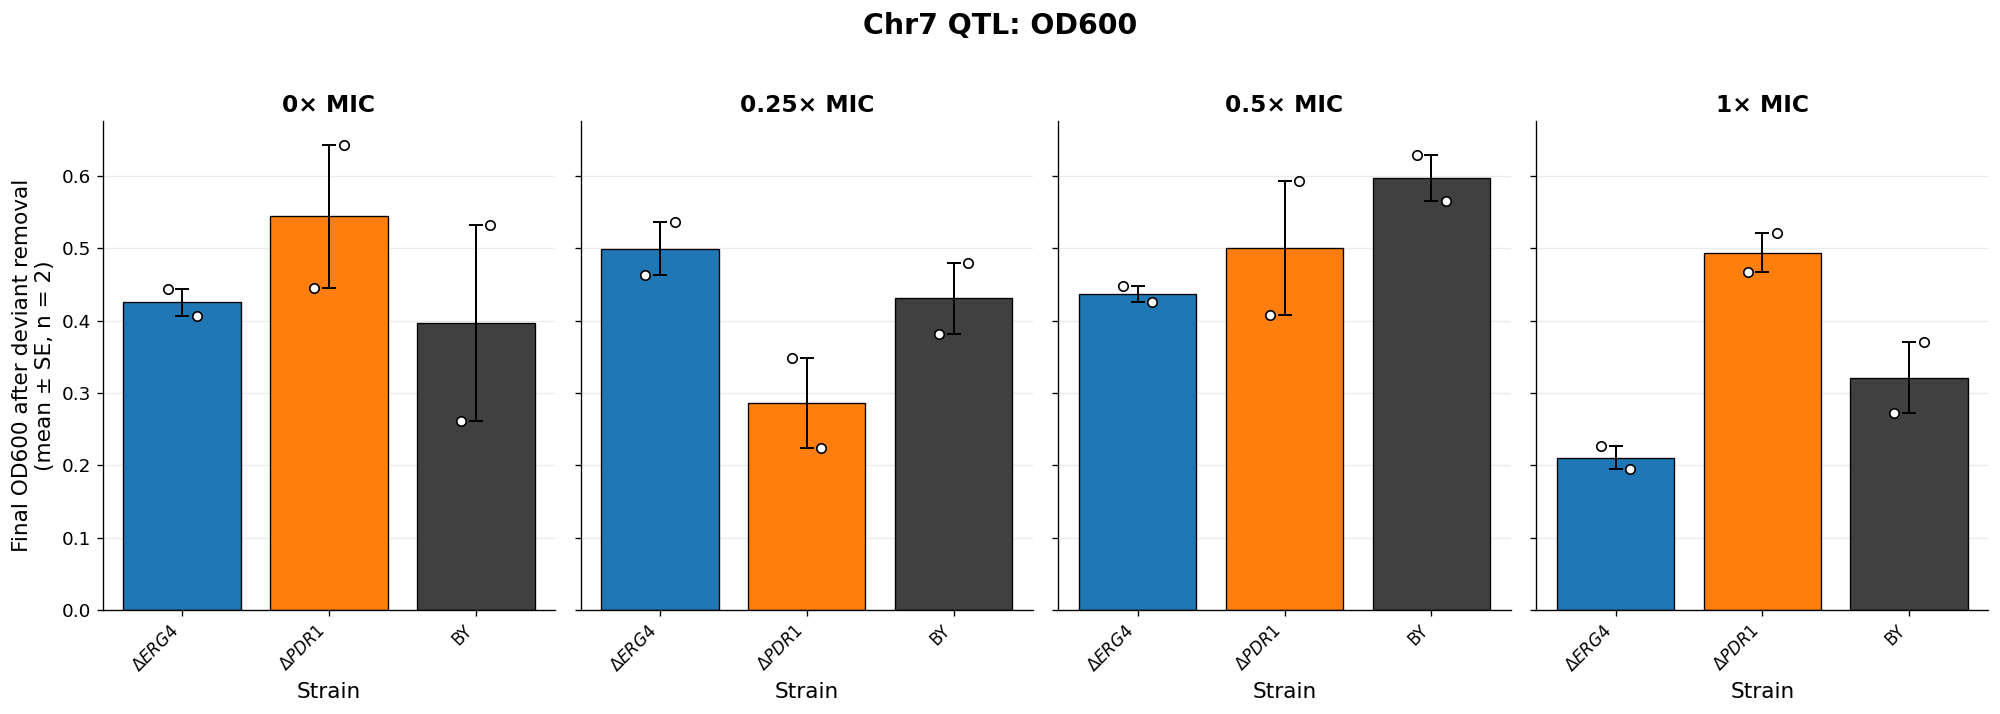

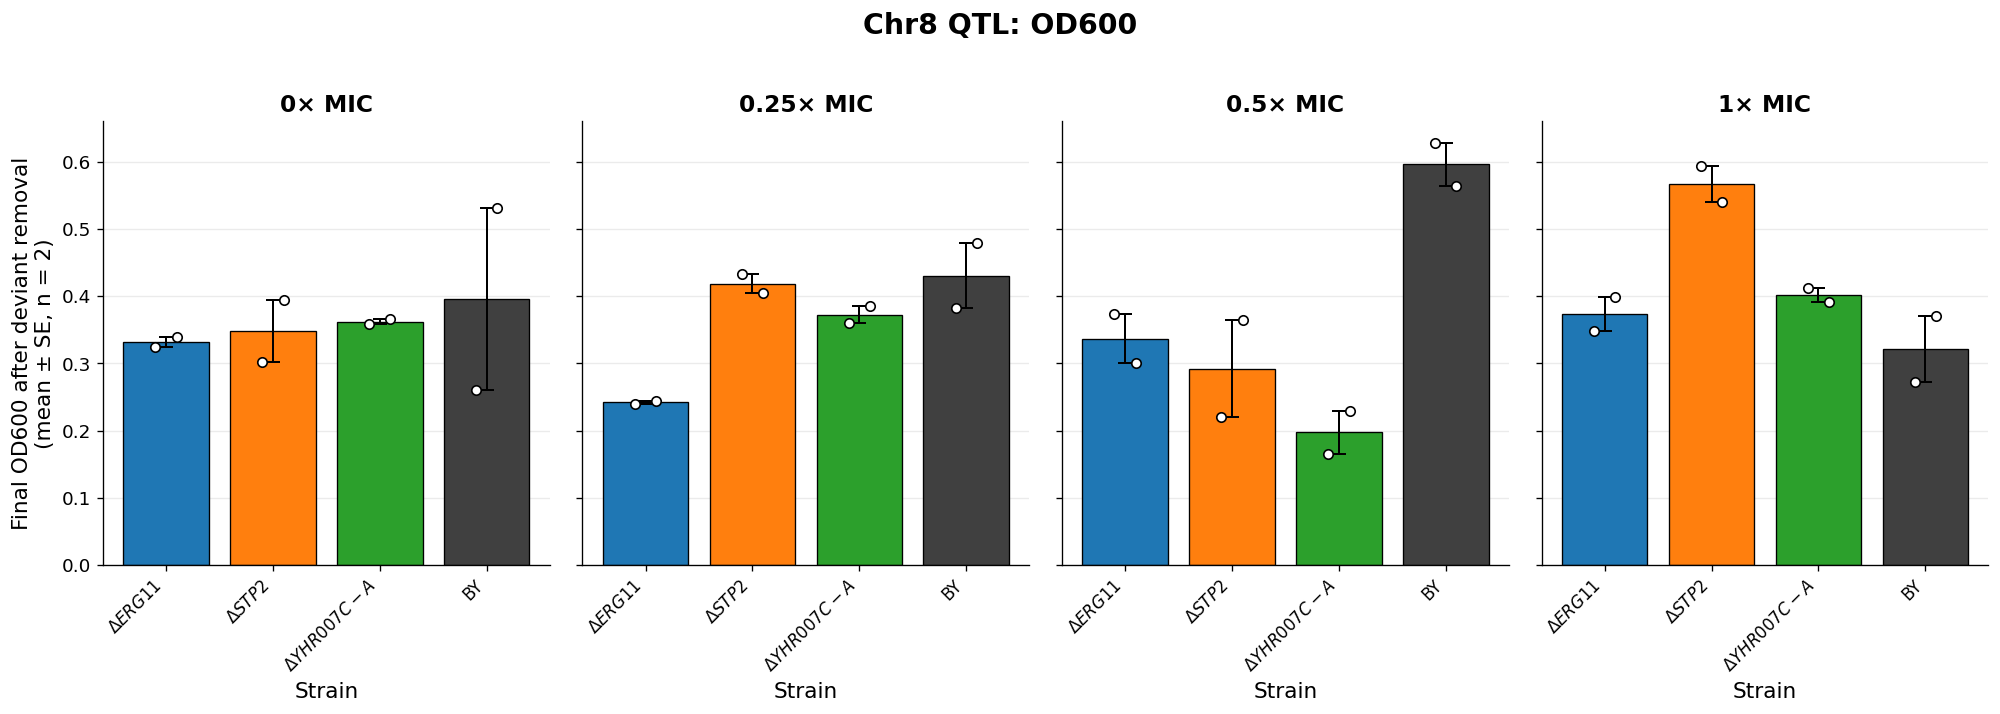

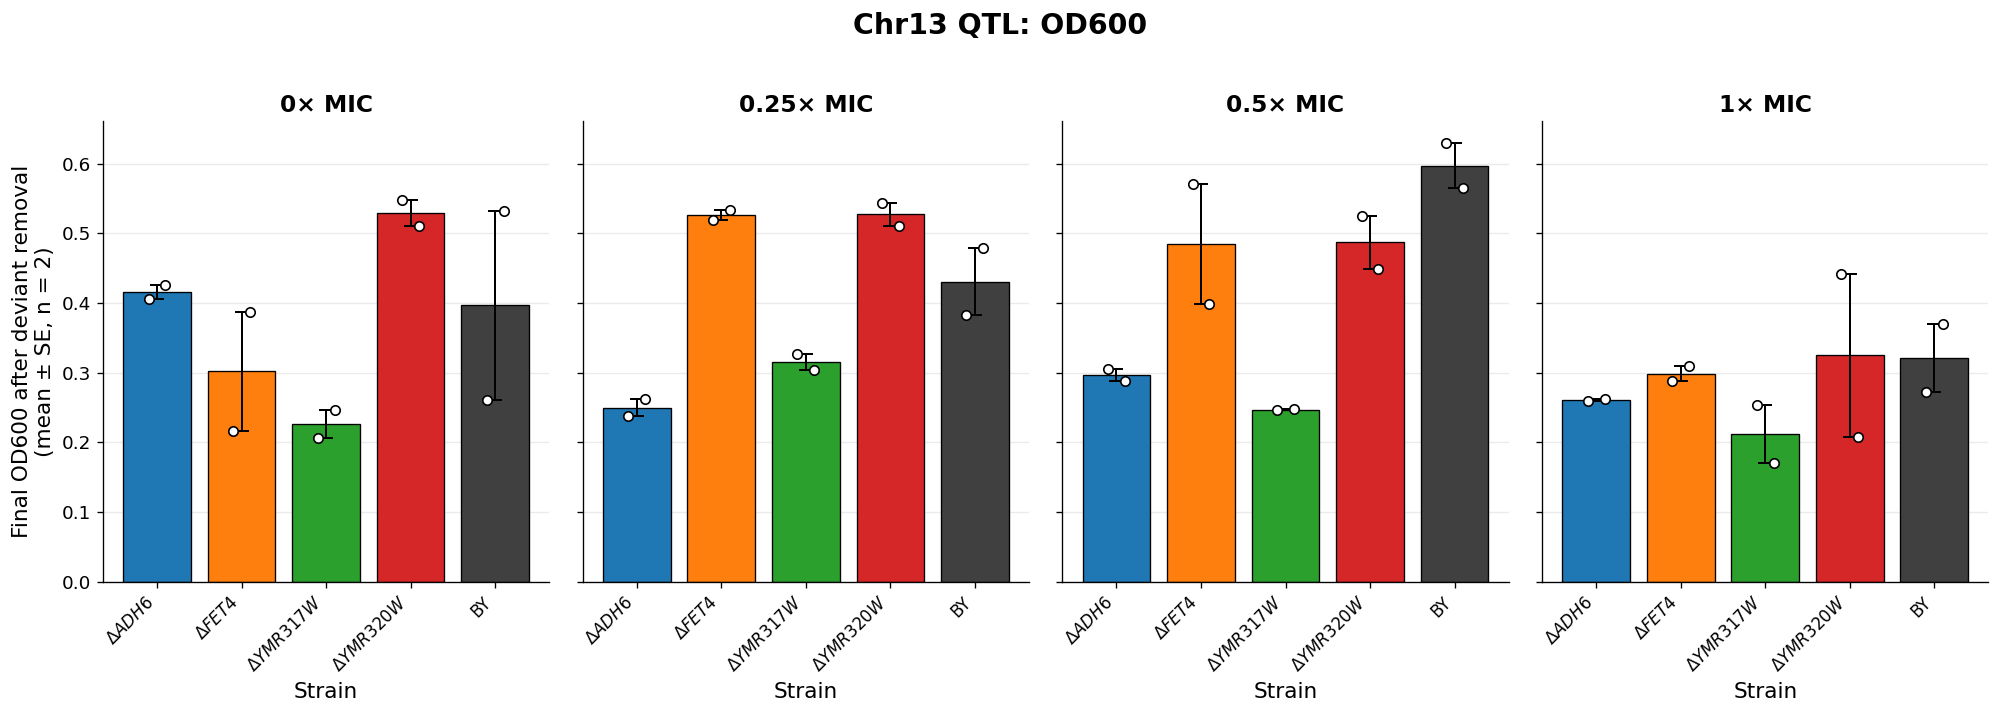

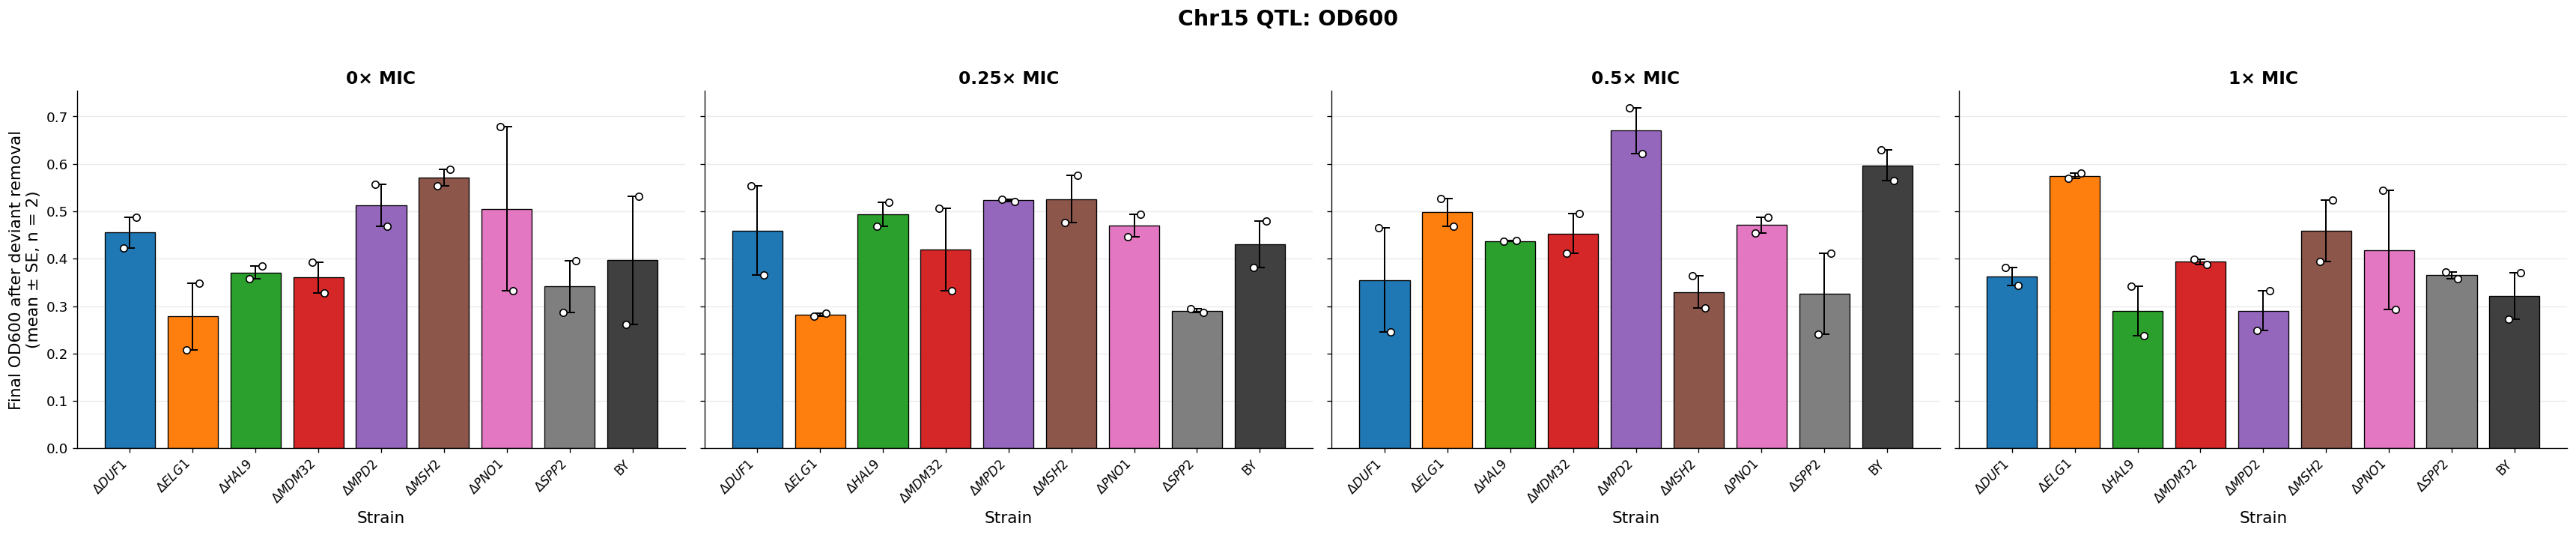


OD600 figures saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/OD600_1x4_figures_deviant_removed


In [11]:
# ==========================================================
# Cell 11 — Generate trimmed OD600 1×4 figures
# ==========================================================

od_figure_paths = []

for qtl_name, summary_df in OD_TRIMMED_SUMMARIES.items():

    output_paths = plot_trimmed_qtl_panels(
        summary_df=summary_df,
        retained_df=qtl_od_trimmed[qtl_name],
        qtl_name=qtl_name,
        raw_metric="OD600",
        metric_name="OD600",
        ylabel=(
            "Final OD600 after deviant removal\n"
            "(mean ± SE, n = 2)"
        ),
        output_dir=OD_OUTDIR,
        concentrations=CONCENTRATION_ORDER,
        add_zero_line=False,
        share_y=True,
        show_replicate_points=True,
        show_figure=True,
    )

    od_figure_paths.extend(
        output_paths
    )

print(
    "\nOD600 figures saved to:",
    OD_OUTDIR
)

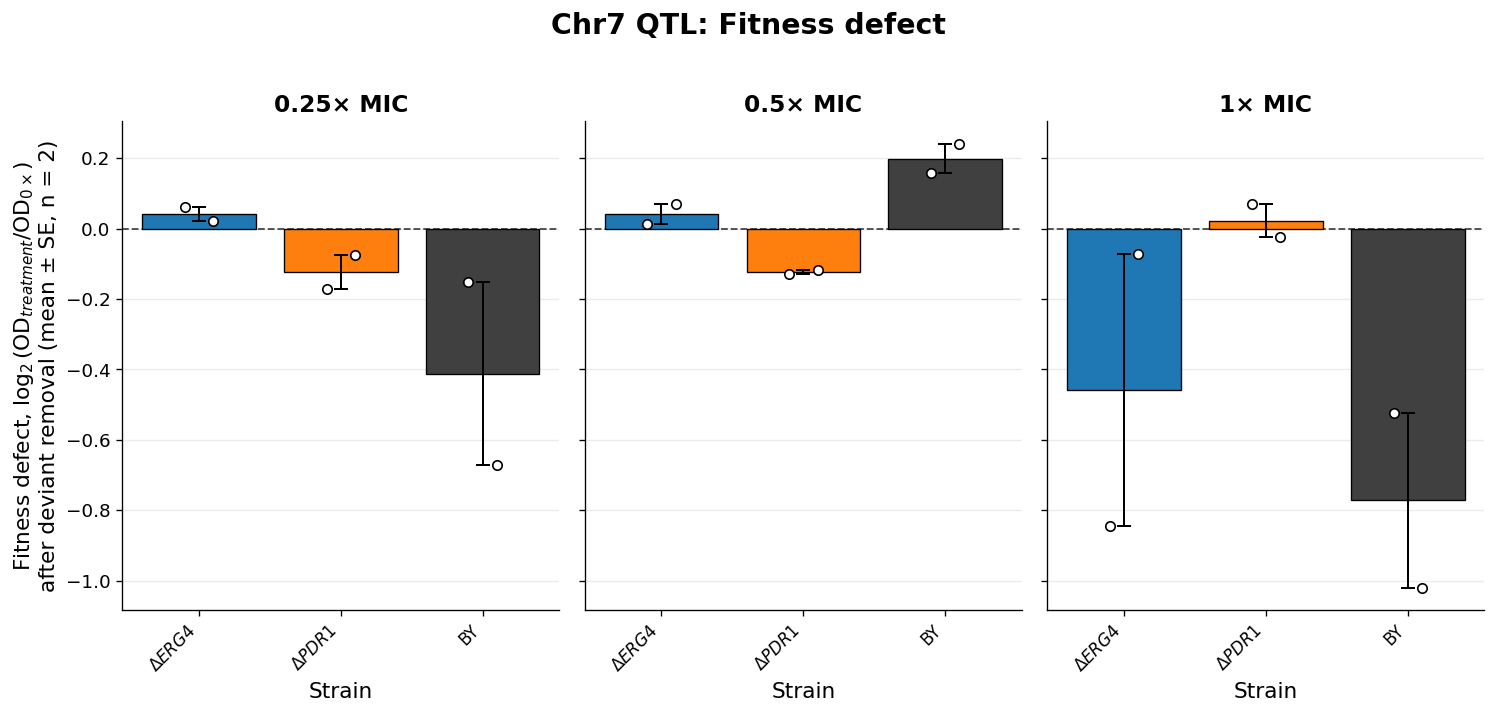

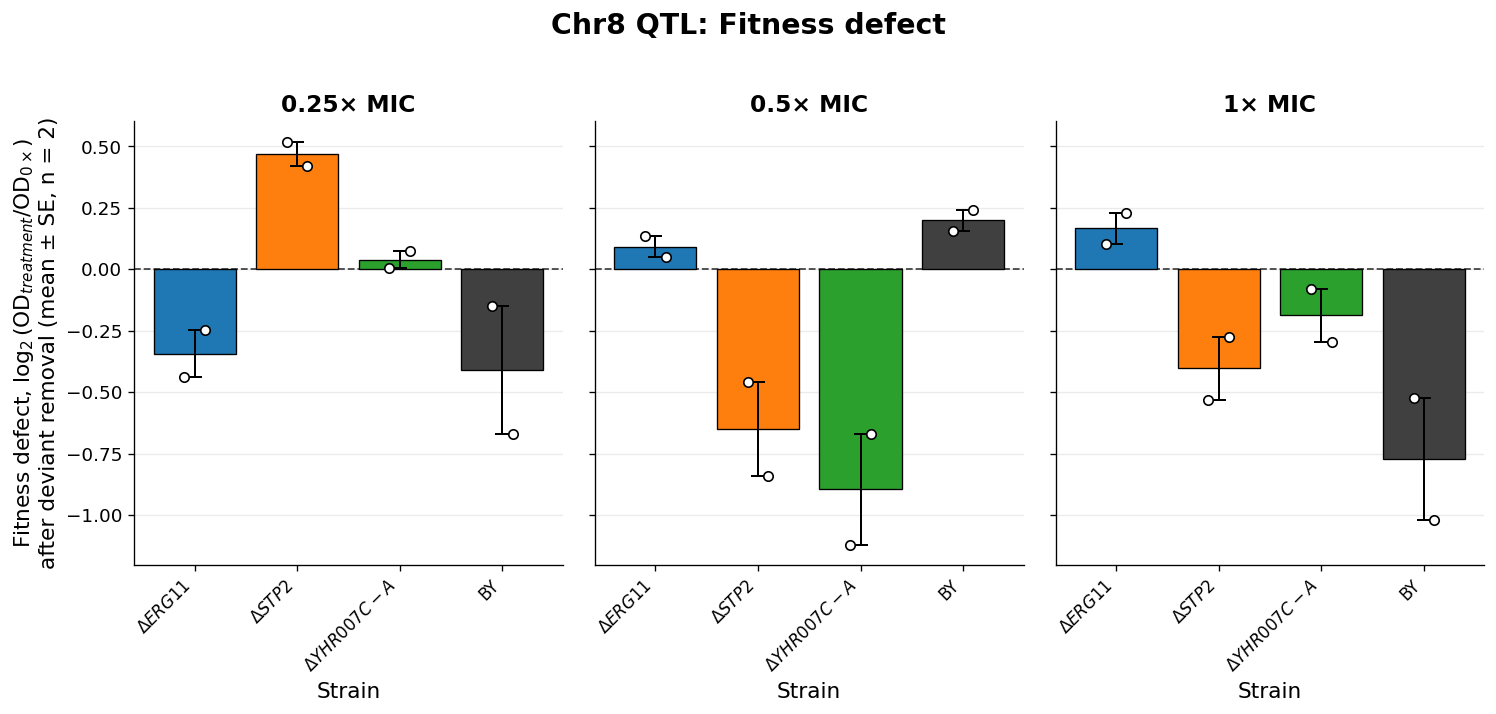

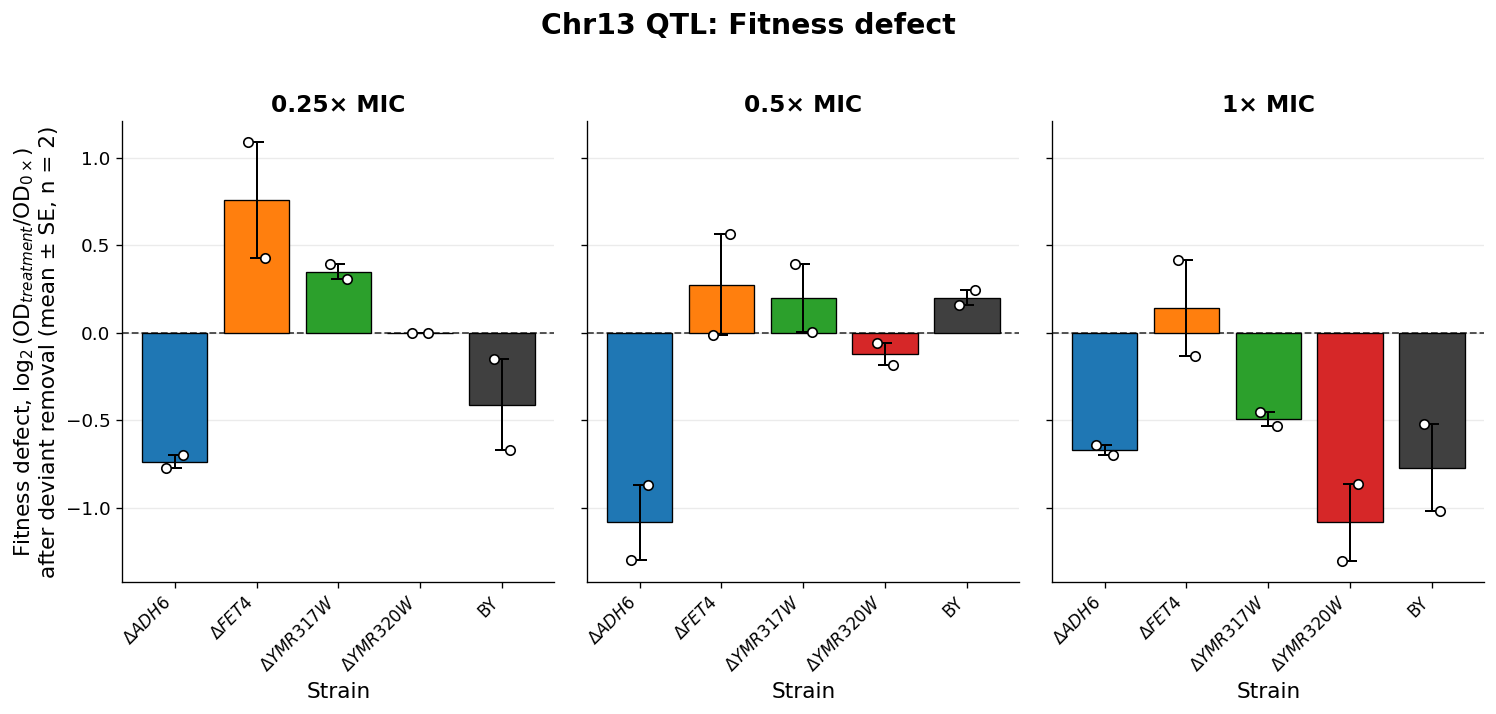

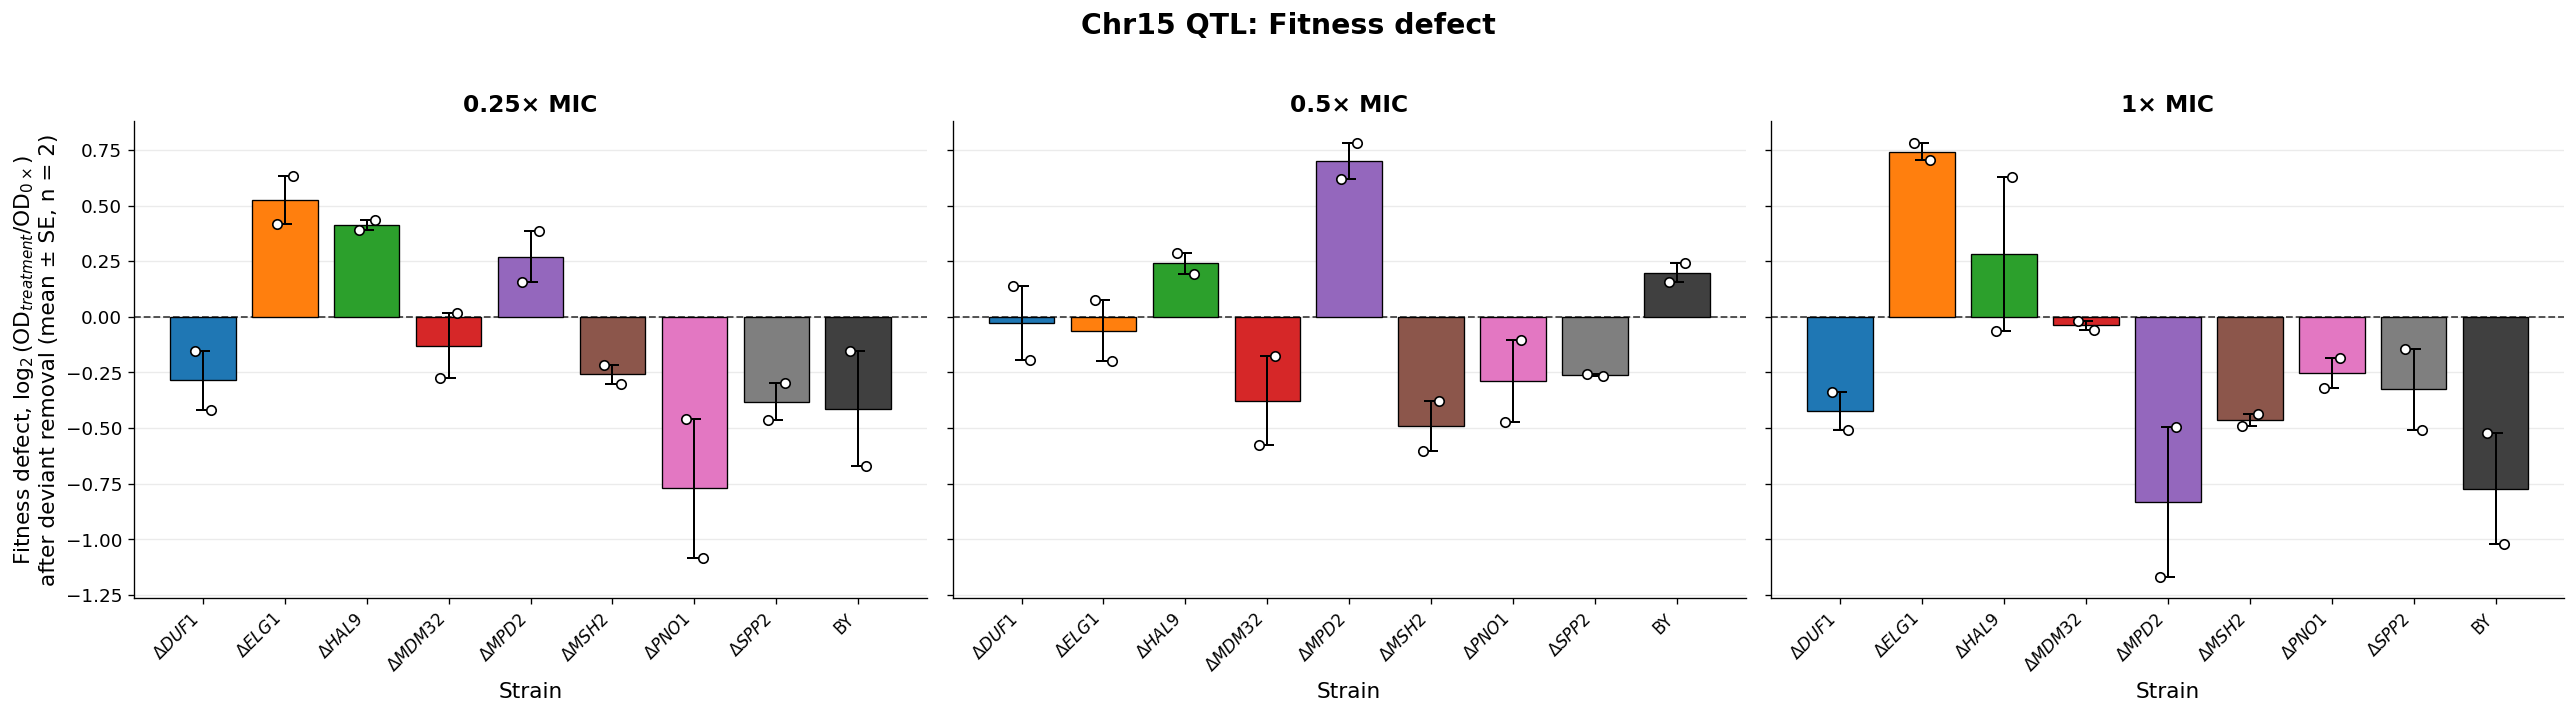


Fitness Defect figures saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/FD_1x4_figures_deviant_removed


In [12]:
# ==========================================================
# Cell 12 — Generate trimmed FD 1×3 figures
# ==========================================================

FD_CONCENTRATION_ORDER = [
    "0.25x",
    "0.50x",
    "1.0x",
]

fd_figure_paths = []

for qtl_name, summary_df in FD_TRIMMED_SUMMARIES.items():

    output_paths = plot_trimmed_qtl_panels(
        summary_df=summary_df,
        retained_df=qtl_fd_trimmed[qtl_name],
        qtl_name=qtl_name,
        raw_metric="FD",
        metric_name="Fitness defect",
        ylabel=(
            r"Fitness defect, "
            r"$\log_2(\mathrm{OD}_{treatment}/"
            r"\mathrm{OD}_{0\times})$"
            "\nafter deviant removal "
            "(mean ± SE, n = 2)"
        ),
        output_dir=FD_OUTDIR,
        concentrations=FD_CONCENTRATION_ORDER,
        add_zero_line=True,
        share_y=True,
        show_replicate_points=True,
        show_figure=True,
    )

    fd_figure_paths.extend(
        output_paths
    )

print(
    "\nFitness Defect figures saved to:",
    FD_OUTDIR
)

In [13]:
# Cell 13 — Export all retained replicate-level data

all_od_retained = pd.concat(
    [
        df.assign(
            Analysis_metric="OD600",
        )
        for qtl_name, df
        in qtl_od_trimmed.items()
    ],
    ignore_index=True,
)


all_fd_retained = pd.concat(
    [
        df.assign(
            Analysis_metric="FD",
        )
        for qtl_name, df
        in qtl_fd_trimmed.items()
    ],
    ignore_index=True,
)


retained_output = pd.concat(
    [
        all_od_retained,
        all_fd_retained,
    ],
    ignore_index=True,
)


retained_output = retained_output[
    [
        "Analysis_metric",
        "QTL",
        "Concentration",
        "Strain",
        "Replicate",
        "OD600",
        "OD600_0x",
        "FD",
        "Source_file",
    ]
]


retained_output_file = (
    SUMMARY_OUTDIR
    / "all_retained_replicate_level_values.csv"
)


retained_output.to_csv(
    retained_output_file,
    index=False,
)


print(
    "Retained replicate-level data saved to:",
    retained_output_file,
)


retained_output


Retained replicate-level data saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables_deviant_removed/all_retained_replicate_level_values.csv


,Analysis_metric,QTL,Concentration,Strain,Replicate,OD600,OD600_0x,FD,Source_file
0,OD600,Chr7 QTL,0x,BY,1,0.261,0.261,0.000000,BY.xlsx
1,OD600,Chr7 QTL,0x,BY,2,0.532,0.532,0.000000,BY.xlsx
2,OD600,Chr7 QTL,0x,ERG4,1,0.444,0.444,0.000000,CHR7_QTL.xlsx
3,OD600,Chr7 QTL,0x,ERG4,2,0.406,0.406,0.000000,CHR7_QTL.xlsx
4,OD600,Chr7 QTL,0x,PDR1,1,0.445,0.445,0.000000,CHR7_QTL.xlsx
...,...,...,...,...,...,...,...,...,...
331,FD,Chr15 QTL,1.0x,MSH2,2,0.524,0.709,-0.436219,CHR15_QTL.xlsx
332,FD,Chr15 QTL,1.0x,PNO1,2,0.544,0.678,-0.317679,CHR15_QTL.xlsx
333,FD,Chr15 QTL,1.0x,PNO1,3,0.293,0.333,-0.184622,CHR15_QTL.xlsx
334,FD,Chr15 QTL,1.0x,SPP2,2,0.358,0.396,-0.145541,CHR15_QTL.xlsx


In [14]:
# Cell 14 — Inspect removed replicates

print("OD600 removals:")
display(
    OD_REMOVAL_LOG
    .sort_values(
        [
            "QTL",
            "Concentration",
            "Strain",
        ]
    )
    .reset_index(drop=True)
)


print("\nFD removals:")
display(
    FD_REMOVAL_LOG
    .sort_values(
        [
            "QTL",
            "Concentration",
            "Strain",
        ]
    )
    .reset_index(drop=True)
)


OD600 removals:


,Concentration,Strain,Metric,Removed_replicate,Removed_value,Group_median,Group_mean,Absolute_distance_from_median,Median_distance_tie,Final_tie_after_mean_check,Remaining_replicates,QTL
0,0.25x,ADH6,OD600,3,0.357,0.262,0.285333,0.095,False,False,"Rep1, Rep2",Chr13 QTL
1,0.25x,BY,OD600,3,0.704,0.479,0.521667,0.225,False,False,"Rep1, Rep2",Chr13 QTL
2,0.25x,FET4,OD600,1,0.459,0.519,0.504000,0.060,False,False,"Rep2, Rep3",Chr13 QTL
3,0.25x,YMR317W,OD600,1,0.270,0.304,0.300000,0.034,False,False,"Rep2, Rep3",Chr13 QTL
4,0.25x,YMR320W,OD600,3,1.544,0.543,0.866000,1.001,False,False,"Rep1, Rep2",Chr13 QTL
...,...,...,...,...,...,...,...,...,...,...,...,...
79,0x,YHR007C-A,OD600,3,0.481,0.366,0.402000,0.115,False,False,"Rep1, Rep2",Chr8 QTL
80,1.0x,BY,OD600,3,0.553,0.370,0.398333,0.183,False,False,"Rep1, Rep2",Chr8 QTL
81,1.0x,ERG11,OD600,3,0.181,0.349,0.309667,0.168,False,False,"Rep1, Rep2",Chr8 QTL
82,1.0x,STP2,OD600,1,0.209,0.541,0.448000,0.332,False,False,"Rep2, Rep3",Chr8 QTL



FD removals:


,Concentration,Strain,Metric,Removed_replicate,Removed_value,Group_median,Group_mean,Absolute_distance_from_median,Median_distance_tie,Final_tie_after_mean_check,Remaining_replicates,QTL
0,0.25x,ADH6,FD,3,-0.559139,-0.701287,-0.677820,0.142148,False,False,"Rep1, Rep2",Chr13 QTL
1,0.25x,BY,FD,1,0.549523,-0.151401,-0.091434,0.700923,False,False,"Rep2, Rep3",Chr13 QTL
2,0.25x,FET4,FD,3,-0.258976,0.423401,0.417296,0.682377,False,False,"Rep1, Rep2",Chr13 QTL
3,0.25x,YMR317W,FD,2,-0.090064,0.305413,0.201888,0.395477,False,False,"Rep1, Rep3",Chr13 QTL
4,0.25x,YMR320W,FD,1,-0.013224,-0.003733,-0.005652,0.009491,False,False,"Rep2, Rep3",Chr13 QTL
...,...,...,...,...,...,...,...,...,...,...,...,...
79,0x,YHR007C-A,FD,3,0.000000,0.000000,0.000000,0.000000,True,True,"Rep1, Rep2",Chr8 QTL
80,1.0x,BY,FD,1,0.059557,-0.523901,-0.495022,0.583458,False,False,"Rep2, Rep3",Chr8 QTL
81,1.0x,ERG11,FD,3,-0.680063,0.102787,-0.115474,0.782851,False,False,"Rep1, Rep2",Chr8 QTL
82,1.0x,STP2,FD,2,0.592267,-0.273662,-0.070813,0.865929,False,False,"Rep1, Rep3",Chr8 QTL
